<a href="https://colab.research.google.com/github/ManasaRubini/Internship/blob/main/Survival_prediction_RandomForest_using_snowflake_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install snowflake-connector-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 2.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Found 

In [3]:
import snowflake.connector
con = snowflake.connector.connect(
    user = "ManasaRubini",
    password = "Shyaamghaneshgmk0206",
    account = "WDRBLRD-YE26672",
    database ="DETAILS",
    schema = "PUBLIC",
    warehouse = "COMPUTE_WH"
)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
query = 'SELECT * FROM titanic'
df = pd.read_sql(query,con)

/tmp/ipykernel_4331/3052456800.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,con)


In [6]:
df.head()

,PASSENGERID,SURVIVED,PCLASS,NAME,SEX,AGE,SIBSP,PARCH,TICKET,FARE,CABIN,EMBARKED
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,None,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,None,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,None,S


In [7]:
df.tail()

,PASSENGERID,SURVIVED,PCLASS,NAME,SEX,AGE,SIBSP,PARCH,TICKET,FARE,CABIN,EMBARKED
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,None,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,None,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,None,Q


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PASSENGERID  891 non-null    int64  
 1   SURVIVED     891 non-null    int64  
 2   PCLASS       891 non-null    int64  
 3   NAME         891 non-null    object 
 4   SEX          891 non-null    object 
 5   AGE          714 non-null    float64
 6   SIBSP        891 non-null    int64  
 7   PARCH        891 non-null    int64  
 8   TICKET       891 non-null    object 
 9   FARE         891 non-null    float64
 10  CABIN        204 non-null    object 
 11  EMBARKED     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
df.describe()

,PASSENGERID,SURVIVED,PCLASS,AGE,SIBSP,PARCH,FARE
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df.shape

(891, 12)

In [11]:
df.isnull().sum()

,0
PASSENGERID,0
SURVIVED,0
PCLASS,0
NAME,0
SEX,0
AGE,177
SIBSP,0
PARCH,0
TICKET,0
FARE,0


In [12]:
df = df.drop('CABIN',axis = 1)

In [13]:
df['AGE'].fillna(df['AGE'].mean(),inplace = True)
df['EMBARKED'].fillna(df['EMBARKED'].mode()[0],inplace = True)

/tmp/ipykernel_4331/2206409910.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AGE'].fillna(df['AGE'].mean(),inplace = True)
/tmp/ipykernel_4331/2206409910.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

<Axes: >

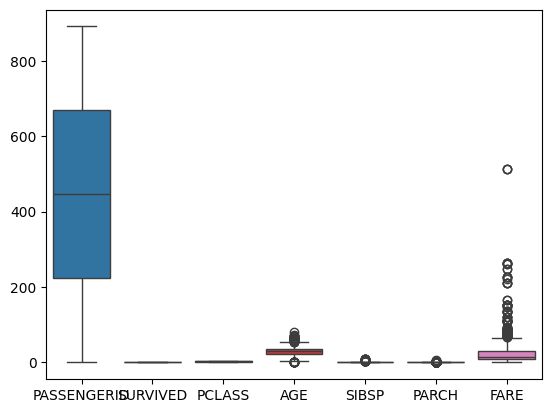

In [14]:
sns.boxplot(df)

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['EMBARKED'] = le.fit_transform(df['EMBARKED'])
df['TICKET'] = le.fit_transform(df['TICKET'])
df['SEX'] = le.fit_transform(df['SEX'])

In [16]:
from scipy.stats.mstats import winsorize
df['AGE'] = winsorize(df['AGE'],limits = [0,0.1])
df['FARE'] = winsorize(df['FARE'],limits = [0,0.1])
df['SIBSP'] = winsorize(df['SIBSP'],limits = [0,0.1])
df['PARCH'] = winsorize(df['PARCH'],limits = [0,0.1])

<Axes: >

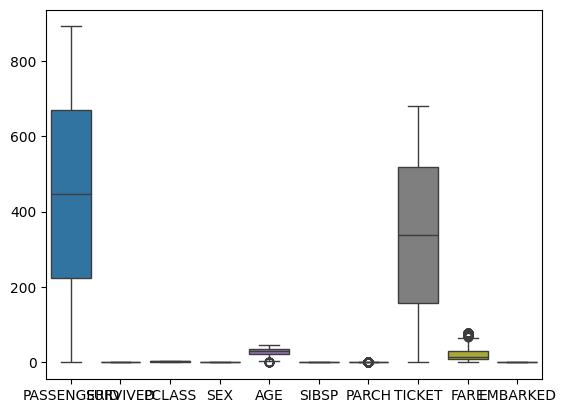

In [17]:
sns.boxplot(df)

In [18]:
x = df.drop(['SURVIVED','NAME'],axis = 1)
y = df['SURVIVED']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import  accuracy_score
model = RandomForestClassifier(
    n_estimators = 100,
    criterion = 'entropy',
    max_depth = 10,
    min_samples_split = 4,
    min_samples_leaf = 2,
    max_features = 'sqrt',
    class_weight = 'balanced',
    random_state = 42
)

model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print('Accuracy = ',accuracy_score(y_pred,y_test))

Accuracy =  0.8379888268156425


[Text(0.38307291666666665, 0.9545454545454546, 'SEX <= 0.5\nentropy = 1.0\nsamples = 451\nvalue = [358.405, 352.015]\nclass = y[0]'),
 Text(0.16666666666666666, 0.8636363636363636, 'PCLASS <= 2.5\nentropy = 0.647\nsamples = 155\nvalue = [48.91, 247.075]\nclass = y[1]'),
 Text(0.27486979166666664, 0.9090909090909092, 'True  '),
 Text(0.08333333333333333, 0.7727272727272727, 'TICKET <= 56.0\nentropy = 0.22\nsamples = 85\nvalue = [6.414, 175.343]\nclass = y[1]'),
 Text(0.05, 0.6818181818181818, 'TICKET <= 50.0\nentropy = 0.584\nsamples = 18\nvalue = [5.613, 34.537]\nclass = y[1]'),
 Text(0.03333333333333333, 0.5909090909090909, 'FARE <= 72.279\nentropy = 0.269\nsamples = 16\nvalue = [1.604, 33.209]\nclass = y[1]'),
 Text(0.016666666666666666, 0.5, 'entropy = 0.0\nsamples = 8\nvalue = [0.0, 19.925]\nclass = y[1]'),
 Text(0.05, 0.5, 'PARCH <= 1.5\nentropy = 0.493\nsamples = 8\nvalue = [1.604, 13.284]\nclass = y[1]'),
 Text(0.03333333333333333, 0.4090909090909091, 'entropy = 0.0\nsamples = 5

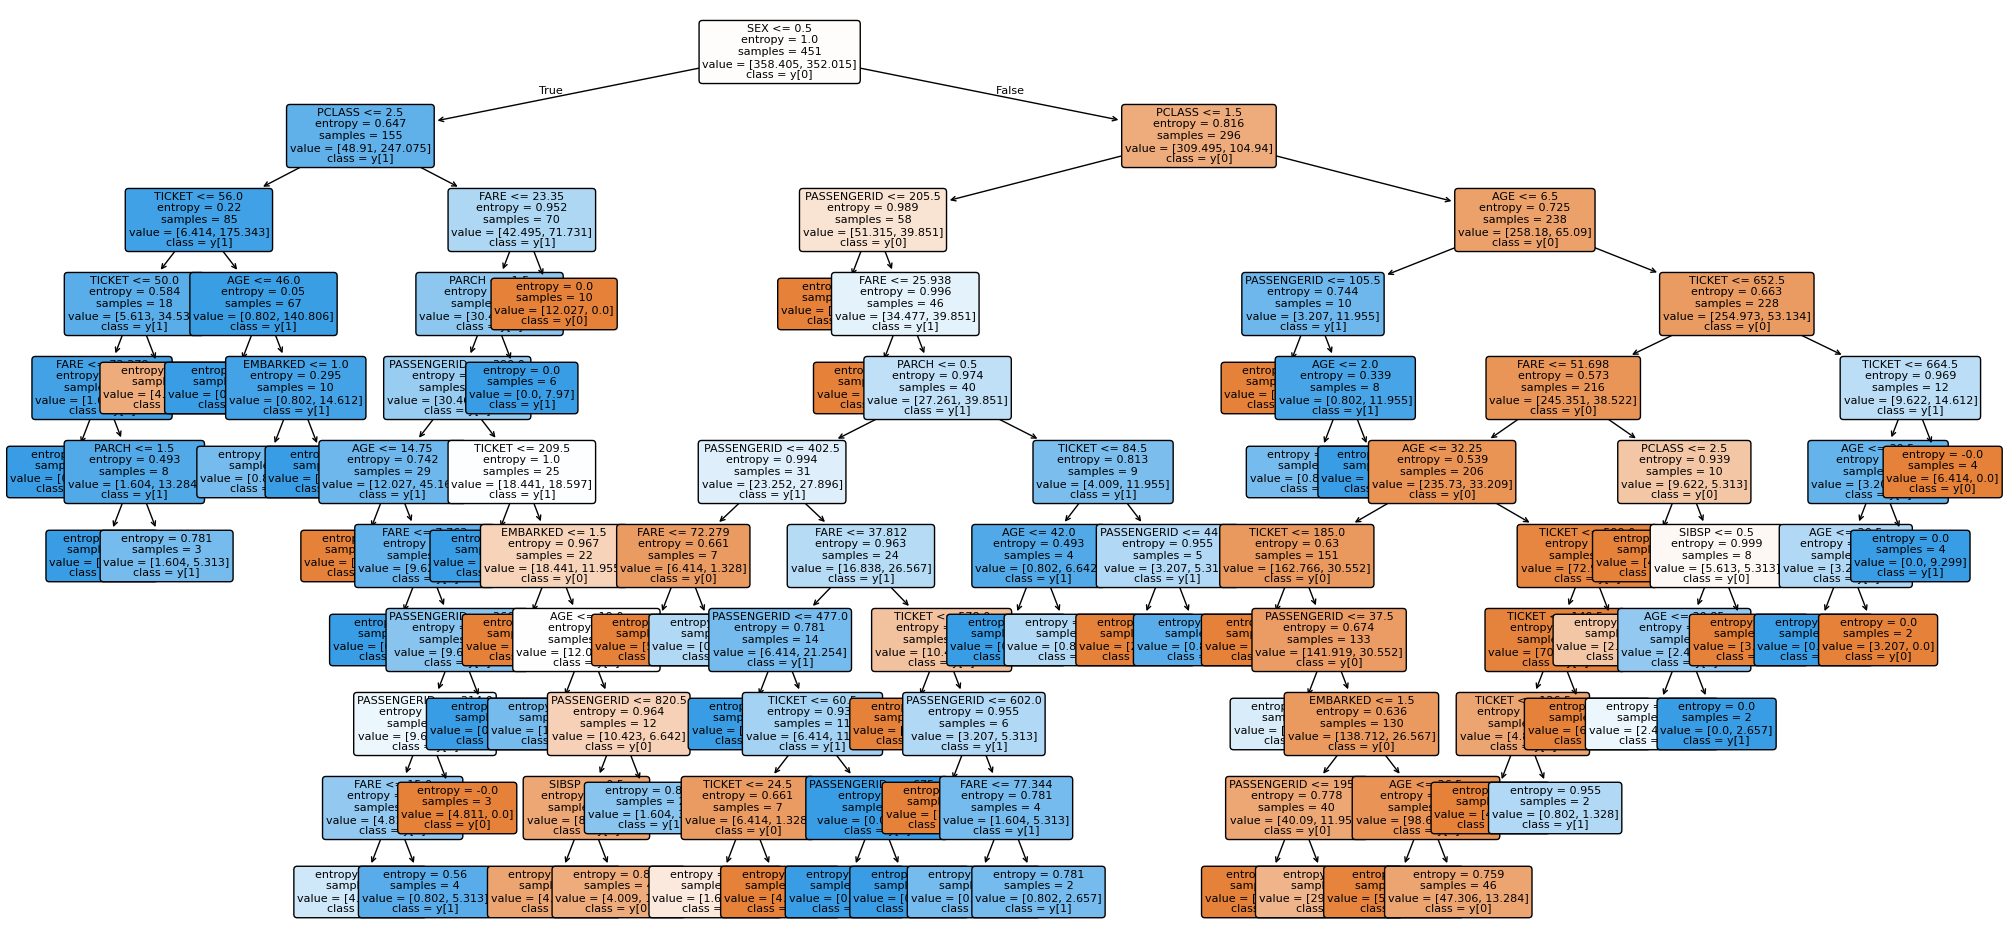

In [21]:
tree = model.estimators_[0]
from sklearn.tree import plot_tree
# Plot tree
plt.figure(figsize=(25,12))

plot_tree(
    tree,
    feature_names=x_train.columns,
    class_names=True,
    filled=True,
    rounded=True,
    fontsize=8
)